<a href="https://colab.research.google.com/github/juandmm12/Proyecto/blob/main/3_clase_titanic_accidentes_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧹 Clase 3: Limpieza de Datos y Consumo de APIs con Pandas
### Dos ejemplos aplicados: el dataset **Titanic** y datos abiertos de **Accidentes de Tránsito en Bucaramanga**

**Objetivo:** Aprender a diagnosticar y tratar valores faltantes, agrupar y resumir información con `groupby`, manipular texto dentro de columnas, consumir datos en vivo desde una API pública para convertirlos en un `DataFrame` analizable, y **visualizar resultados con Matplotlib** (gráficos de líneas y de barras).

**Cómo usar este notebook:**
- Lee las explicaciones en las celdas de texto.
- Ejecuta las celdas de código (`Shift + Enter`) y observa los resultados.
- Resuelve los ejercicios marcados con 🧠 antes de seguir a la siguiente sección.


---

## 1️⃣ Ejemplo 1: Limpieza de datos con el dataset Titanic

El dataset Titanic contiene información de los pasajeros del barco (edad, clase, tarifa, si sobrevivieron, etc.). Es un dataset clásico para practicar **detección y tratamiento de valores faltantes**, porque varias de sus columnas tienen datos incompletos de forma natural.

### 1.1 Cargar el dataset directamente desde una URL

In [ ]:
import pandas as pd
import numpy as np

titanic = pd.read_csv("https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv")
titanic.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### 1.2 Exploración inicial

In [ ]:
titanic.shape          # (filas, columnas)
titanic.columns        # nombres de columnas
titanic.dtypes         # tipo de dato por columna
titanic.info()         # resumen general: tipos y no-nulos


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


🧠 **Ejercicio 1:** Usa `titanic.describe()` para ver las estadísticas de las columnas numéricas. ¿Cuál es la tarifa (`Fare`) promedio pagada por los pasajeros?

In [ ]:
# Tu solución aquí...

titanic.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


---

### 1.3 Detección de valores faltantes (`isnull`)

`isnull()` marca cada celda como `True`/`False` según si está vacía. Sumando esos booleanos por columna (`.sum()`) obtenemos el conteo de valores faltantes.

In [ ]:
titanic.isnull().sum()


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


### 1.4 Tratamiento de valores faltantes (`fillna`, `dropna`)

No existe una única forma correcta de tratar los nulos: depende de la columna y de cuánta información se perdería al eliminarla. Vamos a aplicar tres estrategias distintas sobre tres columnas distintas:

- **`Age`** (numérica, pocos nulos): rellenar con el **promedio** de la columna.
- **`Embarked`** (categórica, muy pocos nulos): rellenar con un valor fijo.
- **`Cabin`** (texto, muchísimos nulos): en vez de perder la columna completa, rellenar cada nulo con un **valor existente elegido al azar** (`np.random.choice`) — útil cuando no queremos introducir un valor artificial nuevo, sino simular que ese dato "faltó" al registrarse.

In [ ]:
T = titanic.copy()

# Age: rellenar con el promedio
T["Age"] = T["Age"].fillna(T["Age"].mean().round(1))

# Embarked: rellenar con un valor fijo
T["Embarked"] = T["Embarked"].fillna("Desconocido")

# Cabin: rellenar con valores existentes elegidos al azar
valores_existentes = T["Cabin"].dropna().values
T["Cabin"] = T["Cabin"].apply(
    lambda x: np.random.choice(valores_existentes) if pd.isna(x) else x
)

T.isnull().sum()


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


🧠 **Ejercicio 2:** Crea una copia nueva llamada `T2` a partir de `titanic` y, en vez de rellenar los nulos, elimínalos directamente con `dropna()`. Compara `T2.shape` contra `titanic.shape`: ¿cuántas filas se perdieron?

In [ ]:
T2 = titanic.copy()
T2 = T2.dropna()
T2.shape
T.dropna()
T.shape



(891, 12)

---

### 1.5 Eliminar columnas que no aportan al análisis (`drop`)

`PassengerId` es solo un identificador secuencial y no aporta información analítica, así que lo eliminamos con `drop(axis=1)`.

In [ ]:
#T = T.drop("PassengerId", axis=1)
T.head()
T.shape

(891, 11)

### 1.6 Agrupar y contar con `groupby` + `size`

`groupby` agrupa filas que comparten un mismo valor en una columna. Combinado con `.size()` podemos contar cuántas filas hay en cada grupo — por ejemplo, cuántos pasajeros compartieron el mismo número de tiquete (lo cual sugiere que viajaban juntos, en familia).

In [ ]:
T["Ticket"].value_counts()

,count
Ticket,
347082,7
1601,7
CA. 2343,7
3101295,6
CA 2144,6
...,...
PC 17590,1
17463,1
330877,1


In [ ]:
boletos = T.groupby("Ticket").size().reset_index().rename(columns={0: "Duplicados"})
boletos = boletos.sort_values("Duplicados", ascending=False)
# boletos.head(10)

boletos


,Ticket,Duplicados
80,1601,7
568,CA. 2343,7
333,347082,7
566,CA 2144,6
249,3101295,6
...,...,...
13,112052,1
12,112050,1
11,111428,1
10,111427,1


In [ ]:
Filtro = T[T["Ticket"] == "CA. 2343"]
Filtro

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
159,0,3,"Sage, Master. Thomas Henry",male,29.7,8,2,CA. 2343,69.55,B4,S
180,0,3,"Sage, Miss. Constance Gladys",female,29.7,8,2,CA. 2343,69.55,D37,S
201,0,3,"Sage, Mr. Frederick",male,29.7,8,2,CA. 2343,69.55,E121,S
324,0,3,"Sage, Mr. George John Jr",male,29.7,8,2,CA. 2343,69.55,E40,S
792,0,3,"Sage, Miss. Stella Anna",female,29.7,8,2,CA. 2343,69.55,B58 B60,S
846,0,3,"Sage, Mr. Douglas Bullen",male,29.7,8,2,CA. 2343,69.55,B58 B60,S
863,0,3,"Sage, Miss. Dorothy Edith ""Dolly""",female,29.7,8,2,CA. 2343,69.55,B22,S


### 1.7 Manipulación de texto en columnas (`.str`)

La columna `Name` tiene el formato `"Apellido, Título. Nombre"`. Usando `.str.split()` podemos separar el apellido del resto del nombre.

In [ ]:
T["Apellido"] = T["Name"].str.split(",").str[0]
T[["Name", "Apellido"]].head()
Filtro = T[T["Ticket"] == "CA. 2343"]
Filtro

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Apellido
159,0,3,"Sage, Master. Thomas Henry",male,29.7,8,2,CA. 2343,69.55,A24,S,Sage
180,0,3,"Sage, Miss. Constance Gladys",female,29.7,8,2,CA. 2343,69.55,B41,S,Sage
201,0,3,"Sage, Mr. Frederick",male,29.7,8,2,CA. 2343,69.55,F G73,S,Sage
324,0,3,"Sage, Mr. George John Jr",male,29.7,8,2,CA. 2343,69.55,A19,S,Sage
792,0,3,"Sage, Miss. Stella Anna",female,29.7,8,2,CA. 2343,69.55,C62 C64,S,Sage
846,0,3,"Sage, Mr. Douglas Bullen",male,29.7,8,2,CA. 2343,69.55,E67,S,Sage
863,0,3,"Sage, Miss. Dorothy Edith ""Dolly""",female,29.7,8,2,CA. 2343,69.55,E8,S,Sage


🧠 **Ejercicio 3 (integrador):** Usando el DataFrame `T`:
1. Agrupa por `Pclass` (clase del pasajero) y `Survived`, y cuenta cuántos pasajeros hay en cada combinación (pista: `groupby([...]).size()`).
2. ¿En qué clase (`Pclass`) sobrevivieron proporcionalmente más pasajeros?

In [ ]:
# Tasa de supervivencia por clase
T["Survived"] = T['Survived'].replace({0: 'Muerto',1:'Vivo'})
Tasa = T.groupby(["Pclass", "Survived"]).size().reset_index().rename(columns={0: "Conteos"})
Tasa

,Pclass,Survived,Conteos
0,1,Muerto,80
1,1,Vivo,136
2,2,Muerto,97
3,2,Vivo,87
4,3,Muerto,372
5,3,Vivo,119


---

## 2️⃣ Ejemplo 2: Consumo de una API pública — Accidentes de Tránsito en Bucaramanga

Ahora vamos a traer datos que **no están en un archivo**, sino que se consultan en vivo desde un portal de datos abiertos ([datos.gov.co](https://www.datos.gov.co)) a través de una API. El dataset contiene el registro de accidentes de tránsito ocurridos en Bucaramanga entre 2012 y 2023, con información como gravedad del accidente, tipo de vehículo involucrado, barrio, comuna y franja horaria.

### 2.1 Consumir la API y convertirla en DataFrame

`pd.read_json()` puede leer directamente una URL que devuelve JSON y convertirlo en `DataFrame`, sin necesidad de pasar manualmente por `requests` + `json.loads()` cuando la estructura es simple (una lista plana de registros).

In [ ]:
import pandas as pd

url = "https://www.datos.gov.co/resource/7cci-nqqb.json"
accidentes = pd.read_json(url)
accidentes

,orden,fecha,a_o,mes,d_a,gravedad,peaton,automovil,campero,camioneta,...,volqueta,moto,bicicleta,otro,barrio,hora,entidad,nombrecomuna,propietario_de_veh_culo,diurnio_nocturno
0,1,2012-01-01T00:00:00.000,2012,01. Enero,07. Domingo,Con heridos,0,1,0,0,...,0,0,0,0,Mutis,1899-12-31T12:15:00.000,AGENTES DTB,17. MUTIS,Particular,Diurno
1,2,2012-01-01T00:00:00.000,2012,01. Enero,07. Domingo,Solo daños,0,1,0,1,...,0,0,0,0,Regaderos Norte,1899-12-31T14:00:00.000,AGENTES DTB,02. NORORIENTAL,Empresa,Diurno
2,3,2012-01-01T00:00:00.000,2012,01. Enero,07. Domingo,Solo daños,0,0,0,1,...,0,0,0,0,Cabecera Del Llano,1899-12-31T12:00:00.000,AGENTES DTB,12. CABECERA DEL LLANO,Particular,Diurno
3,4,2012-01-01T00:00:00.000,2012,01. Enero,07. Domingo,Solo daños,0,1,0,1,...,0,0,0,0,Norte Bajo,1899-12-31T18:30:00.000,AGENTES DTB,03. SAN FRANCISCO,Empresa,Nocturno
4,5,2012-01-01T00:00:00.000,2012,01. Enero,07. Domingo,Con heridos,1,0,0,0,...,0,1,0,0,Dangond,1899-12-31T00:30:00.000,AGENTES DTB,11. SUR,Particular,Nocturno
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996,2012-03-24T00:00:00.000,2012,03. Marzo,06. Sabado,Solo daños,0,1,1,0,...,0,0,0,0,Sotomayor,1899-12-31T08:40:00.000,AGENTES DTB,12. CABECERA DEL LLANO,Empresa,Diurno
996,997,2012-03-24T00:00:00.000,2012,03. Marzo,06. Sabado,Con heridos,0,1,0,0,...,0,1,0,0,La Victoria,1899-12-31T12:45:00.000,AGENTES DTB,06. LA CONCORDIA,Particular,Diurno
997,998,2012-03-25T00:00:00.000,2012,03. Marzo,07. Domingo,Con heridos,0,0,0,0,...,0,1,0,0,Centro,1899-12-31T00:28:00.000,AGENTES DTB,15. CENTRO,Particular,Nocturno
998,999,2012-03-25T00:00:00.000,2012,03. Marzo,07. Domingo,Con heridos,0,0,1,0,...,0,1,0,0,El Prado,1899-12-31T08:00:00.000,AGENTES DTB,13. ORIENTAL,Particular,Diurno


### 2.2 Exploración inicial

Antes de transformar cualquier dato, siempre exploramos primero: cuántas filas y columnas tiene, qué tipos de dato trae cada columna, y si hay valores faltantes.

In [ ]:
accidentes.info()
# accidentes.shape
# accidentes.columns
# accidentes.info()
accidentes.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   orden                    1000 non-null   int64 
 1   fecha                    1000 non-null   object
 2   a_o                      1000 non-null   int64 
 3   mes                      1000 non-null   object
 4   d_a                      1000 non-null   object
 5   gravedad                 1000 non-null   object
 6   peaton                   1000 non-null   int64 
 7   automovil                1000 non-null   int64 
 8   campero                  1000 non-null   int64 
 9   camioneta                1000 non-null   int64 
 10  micro                    1000 non-null   int64 
 11  buseta                   1000 non-null   int64 
 12  bus                      1000 non-null   int64 
 13  camion                   1000 non-null   int64 
 14  volqueta                 1000 non-null   

,0
orden,0
fecha,0
a_o,0
mes,0
d_a,0
gravedad,0
peaton,0
automovil,0
campero,0
camioneta,0


🧠 **Ejercicio 4:** Usa `value_counts()` sobre la columna `gravedad`. ¿Qué proporción de los accidentes registrados fueron "Con heridos" frente a "Solo daños"? (pista: `value_counts(normalize=True)`).

In [ ]:
accidentes['gravedad'].value_counts(normalize=True)*100

,proportion
gravedad,
Solo daños,59.6
Con heridos,39.6
Con muertos,0.8


---

### 2.3 Filtrado de datos

Igual que en la clase anterior, podemos filtrar filas que cumplan una o varias condiciones a la vez.

In [ ]:
# Accidentes con heridos, ocurridos en horario nocturno
filtro = accidentes[
    (accidentes["gravedad"] == "Con heridos") &
    (accidentes["diurnio_nocturno"] == "Nocturno")
]

print("Cantidad de accidentes con heridos en horario nocturno:", len(filtro))
filtro


Cantidad de accidentes con heridos en horario nocturno: 146


,orden,fecha,a_o,mes,d_a,gravedad,peaton,automovil,campero,camioneta,...,volqueta,moto,bicicleta,otro,barrio,hora,entidad,nombrecomuna,propietario_de_veh_culo,diurnio_nocturno
4,5,2012-01-01T00:00:00.000,2012,01. Enero,07. Domingo,Con heridos,1,0,0,0,...,0,1,0,0,Dangond,1899-12-31T00:30:00.000,AGENTES DTB,11. SUR,Particular,Nocturno
24,25,2012-01-04T00:00:00.000,2012,01. Enero,03. Miercoles,Con heridos,0,0,0,0,...,0,2,0,0,La Pedregosa,1899-12-31T20:40:00.000,AGENTES DTB,09. LA PEDREGOSA,Particular,Nocturno
28,29,2012-01-04T00:00:00.000,2012,01. Enero,03. Miercoles,Con heridos,0,1,0,0,...,0,1,0,0,Real De Minas,1899-12-31T18:40:00.000,AGENTES DTB,07. LA CIUDADELA,Particular,Nocturno
31,32,2012-01-05T00:00:00.000,2012,01. Enero,04. Jueves,Con heridos,0,1,0,0,...,0,1,0,0,Conucos,1899-12-31T19:50:00.000,AGENTES DTB,12. CABECERA DEL LLANO,Particular,Nocturno
45,46,2012-01-06T00:00:00.000,2012,01. Enero,05. Viernes,Con heridos,1,0,0,0,...,0,0,0,0,Mejoras Publicas,1899-12-31T20:30:00.000,AGENTES DTB,13. ORIENTAL,Empresa,Nocturno
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
982,983,2012-03-24T00:00:00.000,2012,03. Marzo,06. Sabado,Con heridos,0,0,0,0,...,0,1,0,0,Regaderos Norte,1899-12-31T00:50:00.000,AGENTES DTB,02. NORORIENTAL,Particular,Nocturno
984,985,2012-03-24T00:00:00.000,2012,03. Marzo,06. Sabado,Con heridos,0,0,0,0,...,0,2,0,0,San Miguel,1899-12-31T22:30:00.000,AGENTES DTB,06. LA CONCORDIA,Particular,Nocturno
993,994,2012-03-24T00:00:00.000,2012,03. Marzo,06. Sabado,Con heridos,0,1,0,0,...,0,0,1,0,Universidad,1899-12-31T01:10:00.000,AGENTES DTB,03. SAN FRANCISCO,Particular,Nocturno
994,995,2012-03-24T00:00:00.000,2012,03. Marzo,06. Sabado,Con heridos,0,0,0,0,...,0,2,0,0,Rio de Oro I,1899-12-31T20:55:00.000,AGENTES DTB,04. OCCIDENTAL,Particular,Nocturno


### 2.4 Crear una columna calculada: total de vehículos involucrados

El dataset trae columnas separadas por tipo de vehículo (`automovil`, `campero`, `camioneta`, `volqueta`, `moto`, `bicicleta`, `otro`), cada una en 0/1 indicando si ese tipo estuvo involucrado. Podemos sumarlas para obtener el total de vehículos por accidente.

In [ ]:
columnas_vehiculo = ["automovil", "campero", "camioneta", "volqueta", "moto", "bicicleta", "otro"]

accidentes["Total_Vehiculos"] = accidentes[columnas_vehiculo].sum(axis=1)
accidentes[["fecha", "gravedad"] + columnas_vehiculo + ["Total_Vehiculos"]].head()


,fecha,gravedad,automovil,campero,camioneta,volqueta,moto,bicicleta,otro,Total_Vehiculos
0,2012-01-01T00:00:00.000,Con heridos,1,0,0,0,0,0,0,1
1,2012-01-01T00:00:00.000,Solo daños,1,0,1,0,0,0,0,2
2,2012-01-01T00:00:00.000,Solo daños,0,0,1,0,0,0,0,1
3,2012-01-01T00:00:00.000,Solo daños,1,0,1,0,0,0,0,2
4,2012-01-01T00:00:00.000,Con heridos,0,0,0,0,1,0,0,1


### 2.5 Agrupar por comuna (`groupby` + `agg`)

¿Qué comuna concentra más accidentes registrados? Agrupamos por `nombrecomuna` y contamos, luego ordenamos de mayor a menor.

In [ ]:
accidentes_comuna = accidentes.groupby("nombrecomuna").size().reset_index().rename(columns={0: "Total_Accidentes"})
accidentes_comuna = accidentes_comuna.sort_values("Total_Accidentes", ascending=False)

accidentes['nombrecomuna'].value_counts(normalize=True)*100
accidentes_comuna.head(10)

,nombrecomuna,Total_Accidentes
11,12. CABECERA DEL LLANO,163
2,03. SAN FRANCISCO,143
14,15. CENTRO,123
12,13. ORIENTAL,102
5,06. LA CONCORDIA,80
3,04. OCCIDENTAL,66
9,10. PROVENZA,56
8,09. LA PEDREGOSA,39
4,05. GARCIA ROVIRA,38
19,NO DISPONIBLE,32


In [ ]:
# Usando .agg() para contar
accidentes_comuna = (
    accidentes.groupby("nombrecomuna")
    .agg(Total_Accidentes=("nombrecomuna", "count"))
    .reset_index()
)
accidentes_comuna

,nombrecomuna,Total_Accidentes
0,01. NORTE,31
1,02. NORORIENTAL,14
2,03. SAN FRANCISCO,143
3,04. OCCIDENTAL,66
4,05. GARCIA ROVIRA,38
5,06. LA CONCORDIA,80
6,07. LA CIUDADELA,23
7,08. SUR OCCIDENTE,29
8,09. LA PEDREGOSA,39
9,10. PROVENZA,56


In [ ]:
resumen_vehiculos = accidentes.groupby("gravedad")["Total_Vehiculos"].agg(
    ["count", "mean", "min", "max", "sum"]
)
resumen_vehiculos





,count,mean,min,max,sum
gravedad,,,,,
Con heridos,396,1.659091,0,4,657
Con muertos,8,1.250000,1,2,10
Solo daños,596,1.738255,0,4,1036


🧠 **Ejercicio 5 (integrador):** Sobre el DataFrame `accidentes`:
1. Filtra únicamente los accidentes donde `propietario_de_veh_culo` sea `"Particular"` **y** `gravedad` sea `"Con heridos"`.
2. Agrupa el resultado por `nombrecomuna` y cuenta cuántos accidentes hay en cada una.
3. ¿Cuál es la comuna con más accidentes con heridos en vehículos particulares?

In [ ]:
# Tu solución aquí...


---
## 3️⃣ Visualización de datos con Matplotlib

Hasta ahora hemos **limpiado y resumido** datos con pandas. El siguiente paso natural es **mostrarlos**: un buen gráfico permite ver en segundos lo que en una tabla tomaría minutos.

**Matplotlib** es la librería base de gráficos en Python. En esta sección:
1. Aprenderemos su estructura (figura y ejes).
2. Practicaremos **gráficos de líneas** y **de barras** con datos sintéticos (inventados por nosotros, para concentrarnos en el gráfico y no en los datos).
3. Aplicaremos lo aprendido al dataset **Titanic**.
4. Resolverás un reto con el dataset de **accidentes de Bucaramanga**.

### 3.1 Anatomía de un gráfico: `Figure` y `Axes`

Todo gráfico de Matplotlib tiene dos piezas principales:

- **`Figure` (`fig`)**: el "lienzo" o ventana completa.
- **`Axes` (`ax`)**: el área donde realmente se dibuja el gráfico (con sus ejes X e Y).

La forma recomendada de crearlos es:

```python
fig, ax = plt.subplots()
```

Luego dibujamos sobre `ax` y lo personalizamos con `ax.set_title()`, `ax.set_xlabel()`, `ax.set_ylabel()`, `ax.legend()`, etc. Al final, `plt.show()` muestra el resultado.

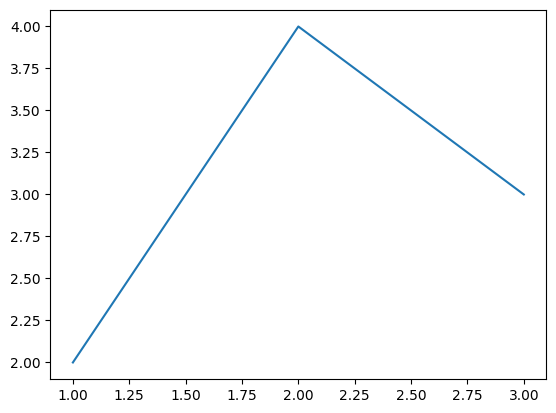

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Un gráfico mínimo: 3 puntos unidos por una línea
fig, ax = plt.subplots()
ax.plot([1, 2, 3], [2, 4, 3])
plt.show()

### 3.2 Gráfico de líneas (`ax.plot`)

El gráfico de líneas es ideal para mostrar **cómo cambia un valor a lo largo del tiempo** (o de cualquier eje ordenado). Vamos a simular las ventas semanales de dos productos durante 12 semanas.

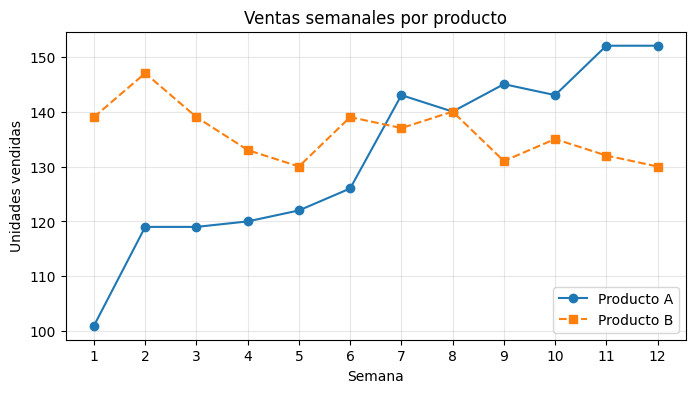

In [ ]:
np.random.seed(42)  # para que todos obtengan los mismos "datos aleatorios"

semanas = np.arange(1, 13)                                   # semanas 1 a 12
ventas_a = 100 + semanas * 5 + np.random.randint(-10, 10, 12)  # producto A: tendencia creciente
ventas_b = 150 - semanas * 2 + np.random.randint(-10, 10, 12)  # producto B: tendencia decreciente

fig, ax = plt.subplots(figsize=(8, 4))   # figsize = (ancho, alto) en pulgadas

ax.plot(semanas, ventas_a, marker="o", color="tab:blue",   label="Producto A")
ax.plot(semanas, ventas_b, marker="s", color="tab:orange", linestyle="--", label="Producto B")

ax.set_title("Ventas semanales por producto")
ax.set_xlabel("Semana")
ax.set_ylabel("Unidades vendidas")
ax.set_xticks(semanas)
ax.legend()
ax.grid(alpha=0.3)

plt.show()

**Parámetros útiles de `ax.plot()`:**

| Parámetro | Qué hace | Ejemplos |
|---|---|---|
| `color` | color de la línea | `"red"`, `"tab:blue"`, `"#2a9d8f"` |
| `marker` | forma del punto | `"o"` círculo, `"s"` cuadrado, `"^"` triángulo |
| `linestyle` | estilo de la línea | `"-"` continua, `"--"` punteada, `":"` puntos |
| `linewidth` | grosor | `1`, `2`, `3` |
| `label` | nombre para la leyenda | `"Producto A"` (requiere `ax.legend()`) |

### 3.3 Gráfico de barras (`ax.bar` y `ax.barh`)

El gráfico de barras sirve para **comparar cantidades entre categorías** (a diferencia de la línea, las categorías no necesitan tener un orden temporal). Vamos a simular las ventas totales por ciudad.

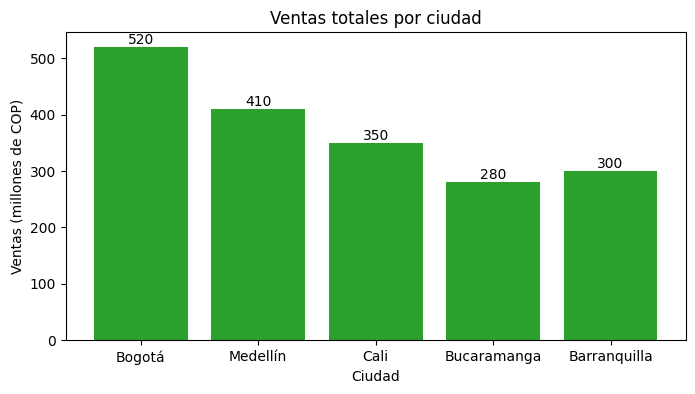

In [ ]:
ciudades = ["Bogotá", "Medellín", "Cali", "Bucaramanga", "Barranquilla"]
ventas   = [520, 410, 350, 280, 300]

fig, ax = plt.subplots(figsize=(8, 4))

barras = ax.bar(ciudades, ventas, color="tab:green")
ax.bar_label(barras)   # escribe el valor encima de cada barra

ax.set_title("Ventas totales por ciudad")
ax.set_xlabel("Ciudad")
ax.set_ylabel("Ventas (millones de COP)")

plt.show()

**Barras horizontales (`ax.barh`)**: útiles cuando los nombres de las categorías son largos (como los nombres de comunas o barrios) y no caben bien debajo de cada barra.

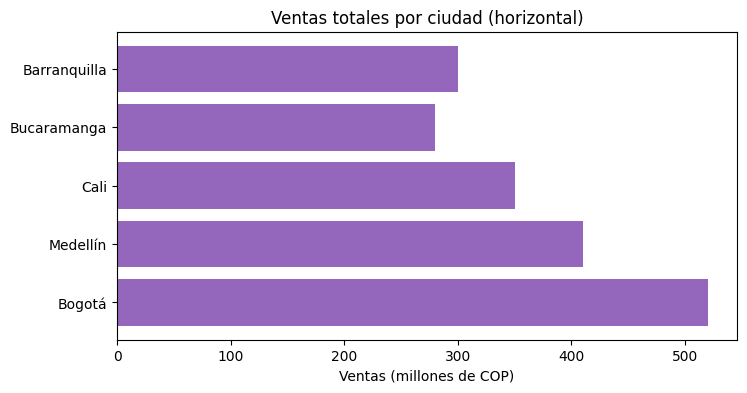

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.barh(ciudades, ventas, color="tab:purple")
ax.set_title("Ventas totales por ciudad (horizontal)")
ax.set_xlabel("Ventas (millones de COP)")

plt.show()

**Barras agrupadas**: para comparar **dos o más series** dentro de cada categoría, desplazamos las barras de cada serie sobre el eje X. La idea: usar posiciones numéricas (`x = np.arange(...)`) y sumar/restar la mitad del ancho de la barra.

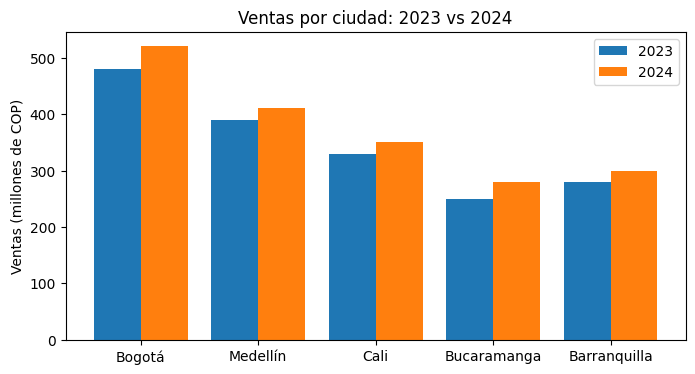

In [ ]:
ventas_2023 = [480, 390, 330, 250, 280]
ventas_2024 = [520, 410, 350, 280, 300]

x = np.arange(len(ciudades))   # posiciones 0, 1, 2, 3, 4
ancho = 0.4                    # ancho de cada barra

fig, ax = plt.subplots(figsize=(8, 4))

ax.bar(x - ancho/2, ventas_2023, width=ancho, label="2023")
ax.bar(x + ancho/2, ventas_2024, width=ancho, label="2024")

ax.set_xticks(x)               # colocamos las etiquetas en el centro de cada grupo
ax.set_xticklabels(ciudades)
ax.set_title("Ventas por ciudad: 2023 vs 2024")
ax.set_ylabel("Ventas (millones de COP)")
ax.legend()

plt.show()

> 💡 **¿Línea o barras?** Usa **líneas** cuando el eje X es una secuencia ordenada (tiempo, edad, semanas) y quieres ver la **tendencia**. Usa **barras** cuando el eje X son **categorías** (ciudades, clases, sexos) y quieres **comparar** magnitudes.

---
### 3.4 Ejemplo aplicado: comparar grupos en el Titanic

Ahora usemos las herramientas de pandas de las secciones anteriores junto con Matplotlib. Pregunta a responder:

> **¿Cómo cambió la tasa de supervivencia según la clase del pasajero (`Pclass`) y el sexo (`Sex`)?**

**Paso 1 – Preparar los datos con pandas.** Como `Survived` vale 1 (sobrevivió) o 0 (no sobrevivió), su **promedio** equivale a la **proporción de sobrevivientes**. Con `unstack()` convertimos el sexo en columnas para poder comparar.

In [ ]:
tasa = T.groupby(["Pclass", "Sex"])["Survived"].mean().unstack() * 100
tasa = tasa.round(1)
tasa

Sex,female,male
Pclass,,
1,96.8,36.9
2,92.1,15.7
3,50.0,13.5


**Paso 2 – Graficar** con barras agrupadas (la misma técnica de la sección 3.3): una barra por sexo dentro de cada clase.

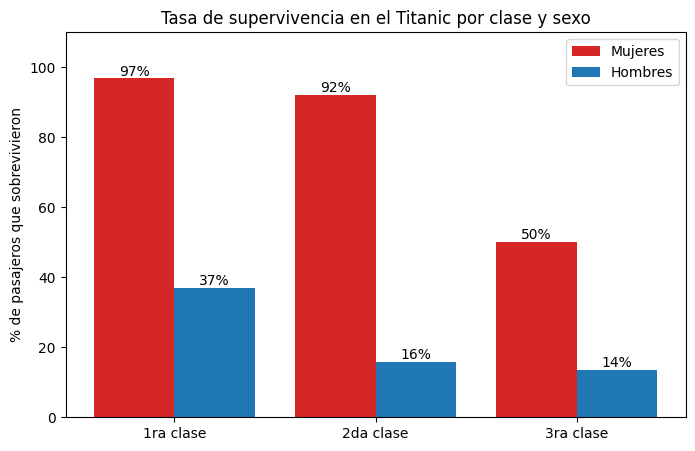

In [ ]:
clases = ["1ra clase", "2da clase", "3ra clase"]
x = np.arange(len(clases))
ancho = 0.4

fig, ax = plt.subplots(figsize=(8, 5))

b1 = ax.bar(x - ancho/2, tasa["female"], width=ancho, label="Mujeres", color="tab:red")
b2 = ax.bar(x + ancho/2, tasa["male"],   width=ancho, label="Hombres", color="tab:blue")

ax.bar_label(b1, fmt="%.0f%%")
ax.bar_label(b2, fmt="%.0f%%")

ax.set_xticks(x)
ax.set_xticklabels(clases)
ax.set_ylim(0, 110)
ax.set_title("Tasa de supervivencia en el Titanic por clase y sexo")
ax.set_ylabel("% de pasajeros que sobrevivieron")
ax.legend()

plt.show()

**Lectura del gráfico:** la brecha entre mujeres y hombres es enorme en todas las clases, y la clase también importa: en 1ra y 2da clase casi todas las mujeres sobrevivieron, mientras que en 3ra clase la tasa baja bastante. Un gráfico permite ver este patrón de un vistazo, algo mucho más difícil de notar en una tabla de números.

🗣️ **Para discutir en clase:** ¿por qué crees que se dieron estas diferencias? ¿Qué otras variables (`Age`, `Fare`) podrían influir?

---
### 🧠 Ejercicio 6 (reto final): graficar los accidentes de Bucaramanga

Usa el DataFrame `accidentes` (sección 2) para construir **un gráfico de barras** que responda:

> **¿En qué día de la semana ocurren más accidentes de tránsito?**

**Pasos sugeridos:**
1. Cuenta los accidentes por día de la semana usando la columna `d_a` (pista: `value_counts()` o `groupby("d_a").size()`).
2. Ordena los días de lunes a domingo (pista: los valores de `d_a` empiezan con un número, como `"01. Lunes"`, así que `sort_index()` los ordena correctamente).
3. Crea el gráfico con `plt.subplots()` y `ax.bar()`.
4. Agrega **título**, **etiquetas de ejes** y, si quieres, el valor sobre cada barra con `ax.bar_label()`.
5. Escribe en una celda de texto **una conclusión** de una o dos frases: ¿qué día es el más crítico?

**⭐ Reto extra:** repite el gráfico pero comparando dos series (por ejemplo, accidentes `Diurno` vs `Nocturno` por día) con barras agrupadas, o cambia a un gráfico de **líneas** usando la columna `mes`.

In [ ]:
# Tu solución aquí...

<details>
<summary>👨‍🏫 <b>Solución de referencia (para el docente — no abrir antes de intentarlo)</b></summary>

```python
conteo = accidentes["d_a"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(9, 4))
barras = ax.bar(conteo.index, conteo.values, color="tab:red")
ax.bar_label(barras)

ax.set_title("Accidentes de tránsito por día de la semana (Bucaramanga)")
ax.set_xlabel("Día de la semana")
ax.set_ylabel("Número de accidentes")
plt.xticks(rotation=30)   # rota las etiquetas para que no se solapen
plt.show()
```

Nota: la API devuelve por defecto solo 1000 registros, por lo que la conclusión aplica a esa muestra.
</details>

---
## ✅ Resumen de la clase

| Tema | Conceptos clave |
|---|---|
| Exploración | `shape`, `columns`, `dtypes`, `info()`, `describe()` |
| Valores faltantes | `isnull().sum()`, `fillna()` (valor fijo, promedio, `np.random.choice`), `dropna()` |
| Limpieza | `copy()`, `drop(axis=1)` |
| Agrupación | `groupby().size()`, `groupby().agg()`, `reset_index()`, `rename()` |
| Texto en pandas | `.str.split()` |
| Ordenar | `sort_values()` |
| Filtrado | condiciones simples y combinadas con `&` |
| Columnas calculadas | operaciones entre columnas, `.sum(axis=1)` |
| Consumo de APIs | `pd.read_json(url)` para convertir una API JSON directamente en `DataFrame` |
| Matplotlib básico | `plt.subplots()`, `ax.plot()`, `ax.bar()`, `ax.barh()`, títulos, etiquetas, leyenda, `grid`, `plt.show()` |
| Visualizar con pandas | `groupby().mean().unstack()` → barras agrupadas con `ax.bar()` |